In [1]:
# Imports 
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision
import mediapipe as mp
from mediapipe.tasks import python
import matplotlib.pyplot as plt
import pandas as pd 
import pickle as pkl
from tqdm import tqdm
import os 
from PIL import Image
import cv2
import csv
from pathlib import Path

 


In [2]:
PATH = "C:/Users/leahz/Documents/ATC/pose-project/data"
input = f"{PATH}/099920730.jpg"

In [3]:
features = {
    "head" : [(8,7), (10,9), (8,10), (7,9)],
    "torso" : [(12,11), (24,23), (12,24), (11,23)],
    "left-leg": [(24,26), (26,28)],
    "right-leg": [(23,25), (25,27)],
    "legs":[(24,23), (26,25), (28,27), (30,32), (29,31)],
    "left-arm": [(12,14), (14,16)], 
    "right-arm": [(11,13), (13,15)],
    "full-body":[(0,24), (0,23), (0,12), (0,11)]
}

In [4]:
def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

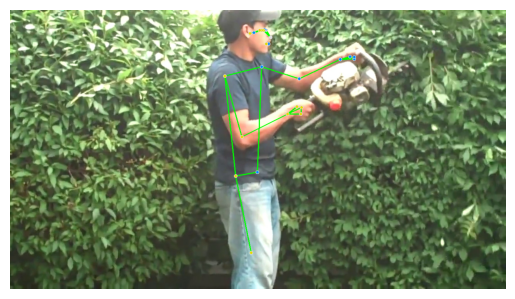

In [5]:
# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path=f'{PATH}/pose_landmarker_full.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)


# STEP 3: Load the input image.
# image = mp.Image.create_from_file(f"{PATH}/mpii_human_pose_v1/images/000004812.jpg")
image = mp.Image.create_from_file(f"{PATH}/mpii_human_pose_v1/images/099920730.jpg")


# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)


# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)


plt.imshow(annotated_image)
plt.axis('off')
plt.show()

In [6]:
detection_result

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.5251737833023071, y=0.0974571704864502, z=-0.048505671322345734, visibility=0.9997201561927795, presence=0.9994076490402222, name=None), NormalizedLandmark(x=0.5156807899475098, y=0.07189589738845825, z=-0.022527512162923813, visibility=0.9995816349983215, presence=0.9990813732147217, name=None), NormalizedLandmark(x=0.5145330429077148, y=0.07129353284835815, z=-0.02260817214846611, visibility=0.9994851350784302, presence=0.9991005659103394, name=None), NormalizedLandmark(x=0.5127873420715332, y=0.0707206130027771, z=-0.02263367734849453, visibility=0.9995818734169006, presence=0.999021053314209, name=None), NormalizedLandmark(x=0.5112477540969849, y=0.07296949625015259, z=-0.06786629557609558, visibility=0.9996775388717651, presence=0.9990984201431274, name=None), NormalizedLandmark(x=0.5075831413269043, y=0.07320600748062134, z=-0.06791456043720245, visibility=0.9996541738510132, presence=0.9989933371543884, name=None), Nor

# Skeleton Sketch

In [7]:
import numpy as np
import cv2

class Skeleton:
    def __init__(self, joints, edges, joint_meta=None, edge_meta=None):
        self.joints = joints.astype(float)              
        self.edges = edges.astype(int)                  

        self.joint_meta = joint_meta if joint_meta else [{} for _ in range(len(joints))]
        self.edge_meta = edge_meta if edge_meta else [{} for _ in range(len(edges))]

    def jitter_joints(self, sigma=0.01):
        noise = np.random.normal(0, sigma, self.joints.shape)
        self.joints += noise

    def _scale_line(self, p1, p2, scale):
        p1, p2 = np.array(p1), np.array(p2)
        mid = (p1 + p2) / 2.0
        vec = p2 - p1
        new_p1 = mid - (vec * scale) / 2.0
        new_p2 = mid + (vec * scale) / 2.0
        return tuple(new_p1.astype(int)), tuple(new_p2.astype(int))

    def _get_bezier_curve(self, p1, p2, bend_factor=0.3, num_points=15):
        """Generates points for a quadratic Bezier curve."""
        p1, p2 = np.array(p1), np.array(p2)
        mid = (p1 + p2) / 2.0
        perp = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])
        control = mid + perp * bend_factor
        t = np.linspace(0, 1, num_points)[:, np.newaxis]
        curve = (1 - t)**2 * p1 + 2 * (1 - t) * t * control + t**2 * p2
        return curve.astype(np.int32)

    def _get_line_segments(self, p1, p2, num_segments=10):
        """Chops a straight line into points to allow for varying thickness."""
        x_vals = np.linspace(p1[0], p2[0], num_segments)
        y_vals = np.linspace(p1[1], p2[1], num_segments)
        return np.vstack((x_vals, y_vals)).T.astype(np.int32)

    def render(self, size=256, noise_level=3):
        canvas = np.zeros((size, size, 4), dtype=np.uint8)
        
        # --- Z-AXIS NORMALIZATION FOR OPACITY ---
        z_vals = self.joints[:, 2]
        z_min, z_max = np.min(z_vals), np.max(z_vals)
        z_range = (z_max - z_min) if (z_max - z_min) > 0 else 1.0
        
        def get_alpha(z_value):
            normalized_z = 1.0 - ((z_value - z_min) / z_range)
            return int(normalized_z * 205 + 50)
        
        # --- HEAD ELLIPSE LOGIC ---
        p7 = self.joints[7][:2] * size
        p8 = self.joints[8][:2] * size
        p4 = self.joints[4][:2] * size
        p1 = self.joints[1][:2] * size
        p0 = self.joints[0][:2] * size 

        r1 = int(np.linalg.norm(p8 - p7) / 2)
        mid_4_1 = (p4 + p1) / 2.0
        r2 = int(2 * np.linalg.norm(mid_4_1 - p0))
        
        head_alpha = get_alpha(self.joints[0, 2])
        cv2.ellipse(canvas, center=tuple(p0.astype(int)), axes=(r1, r2), 
                    angle=0, startAngle=0, endAngle=360, color=(0, 0, 0, head_alpha), thickness=2)

        # --- DRAW EDGES ---
        for (i, (a, b)) in enumerate(self.edges):
            meta = self.edge_meta[i]
            if not meta.get("visible", True) or meta.get("category") == "head":
                continue 

            p1 = tuple((self.joints[a, :2] * size).astype(int))
            p2 = tuple((self.joints[b, :2] * size).astype(int))

            scale = meta.get("length_scale", 1.0)
            if scale != 1.0:
                p1, p2 = self._scale_line(p1, p2, scale)

            avg_z = (self.joints[a, 2] + self.joints[b, 2]) / 2.0
            alpha = get_alpha(avg_z)
            color = (0, 0, 0, alpha) 
            
            base_thickness = meta.get("thickness", 2)
            strokes = meta.get("sketch_strokes", 1)

            for stroke in range(strokes):
                # Apply random overall jitter to this specific stroke
                sp1 = (p1[0] + np.random.randint(-noise_level, noise_level + 1), 
                       p1[1] + np.random.randint(-noise_level, noise_level + 1))
                sp2 = (p2[0] + np.random.randint(-noise_level, noise_level + 1), 
                       p2[1] + np.random.randint(-noise_level, noise_level + 1))

                # Get points for segments (either curve or straight line)
                if meta.get("style") == "curve":
                    jittered_bend = meta.get("bend", 0.3) + np.random.uniform(-0.05, 0.05)
                    pts = self._get_bezier_curve(sp1, sp2, bend_factor=jittered_bend)
                else:
                    # Determine segments based on line length so long lines have more variance points
                    length = np.linalg.norm(np.array(sp1) - np.array(sp2))
                    num_segments = max(4, int(length // 15)) 
                    pts = self._get_line_segments(sp1, sp2, num_segments)

                # Draw the line segment by segment, varying the thickness at each step
                for pt_idx in range(len(pts) - 1):
                    seg_p1 = tuple(pts[pt_idx])
                    seg_p2 = tuple(pts[pt_idx + 1])
                    
                    # VARYING WIDTH: Waver around the base thickness (+/- 1 pixel)
                    current_thickness = max(1, base_thickness + np.random.randint(-1, 2))
                    
                    cv2.line(canvas, seg_p1, seg_p2, color=color, thickness=current_thickness)

        # --- DRAW JOINTS ---
        for i, joint in enumerate(self.joints):
            meta = self.joint_meta[i]
            if not meta.get("visible", True):
                continue

            center = tuple((joint[:2] * size).astype(int))
            alpha = get_alpha(joint[2])
            color = (0, 0, 0, alpha)

            cv2.circle(canvas, center, radius=2, color=color, thickness=-1)
            
            if meta.get("draw_outer_ring"):
                ring_r = meta.get("ring_radius", 6)
                ring_center = (center[0] + np.random.randint(-2, 3), center[1] + np.random.randint(-2, 3))
                # Even the circles can have a tiny thickness variation
                cv2.circle(canvas, ring_center, radius=ring_r, color=color, 
                           thickness=max(1, np.random.randint(1, 3)))

        return canvas

In [8]:
# joints is all the landmarks 
# edges are the tuples of indices into the joints array that define the skeleton structure that I choose
edges = [
    # head 
    (8,6),(6,5),(5,4),(4,0),(0,1),(1,2),(2,3),(3,7),(10,9),
    # torso
    (12,11), (24,23), (12,24), (11,23),
    # left-leg
    (24,26), (26,28),
    # right-leg
    (23,25), (25,27),
    # left-arm
    (12,14), (14,16),
    # right-arm
    (11,13), (13,15),
    # left foot
    (28,30), (30,32), (32,28),
    # right foot
    (27,29), (29,31), (31,27),
    # left hand
    (16,18), (18,20), (20,16), (16,22),
    # right hand
    (15,17), (17,19), (19,15), (15,21)
]

JOINT_CATEGORIES = {
    "head": [0,1,2,3,4,5,6,7,8,9,10],
    "torso": [11,12,23,24],
    "left_arm": [11,13,15],
    "right_arm": [12,14,16],
    "left_leg": [23,25,27],
    "right_leg": [24,26,28],
    "left_hand": [15,17,18,19,20,22],
    "right_hand": [16,18,19,20,21],
    "left_foot": [28,30,32],
    "right_foot": [27,29,31]
}




In [9]:
def stylize_as_sketch(skeleton):
    # 1. Add circles to specific joints
    target_joints = [11, 12, 13, 14, 25, 26]
    for idx in target_joints:
        skeleton.joint_meta[idx]["draw_outer_ring"] = True
        skeleton.joint_meta[idx]["ring_radius"] = np.random.randint(2, 8) # Varying sizes

    # 2. Torso Logic: Bulge thinner rectangles
    # Measure shoulder width (11 to 12) vs torso height (11 to 23)
    p11, p12, p23 = skeleton.joints[11], skeleton.joints[12], skeleton.joints[23]
    width = np.linalg.norm(p12 - p11)
    height = np.linalg.norm(p23 - p11)
    
    # Find the edges corresponding to the torso sides and curve them if thin
    if width / (height + 1e-5) < 0.6: # If thin
        for i, (a, b) in enumerate(skeleton.edges):
            if (a, b) in [(12, 24), (11, 23), (24, 12), (23, 11)]: # Left and right sides
                skeleton.edge_meta[i]["style"] = "curve"
                # Bend left side left, right side right
                skeleton.edge_meta[i]["bend"] = 0.3 if a in [12, 24] else -0.3 

    # 3. Arms/Legs: Sketchy, overlapping lines & Length variation
    sketch_categories = ["left_arm", "right_arm", "left_leg", "right_leg"]
    for i, (a, b) in enumerate(skeleton.edges):
        cat_a = skeleton.joint_meta[a].get("category")
        cat_b = skeleton.joint_meta[b].get("category")
        
        if cat_a in sketch_categories or cat_b in sketch_categories:
            # Tell the renderer to draw 3 jittery lines instead of 1
            skeleton.edge_meta[i]["sketch_strokes"] = 3
            
            # Randomly make the line 10% shorter (0.9) to 20% longer (1.2)
            skeleton.edge_meta[i]["length_scale"] = np.random.uniform(0.9, 1.2)
            
    return skeleton

In [10]:
def construct_skeleton_from_mediapipe_result(
    detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.15,
):
    """
    Constructs a Skeleton from a MediaPipe detection result.

    Args:
        detection_result: MediaPipe pose detection result.
        edges: list of (start, end) tuples defining the skeleton connectivity.
        normalize_to_bbox: if True, re-center and scale landmarks to fit [0, 1]
            based on the detected pose box.
        bbox_padding: relative padding added around the pose bbox.

    Returns:
        Skeleton instance with joints, edges, joint_meta, and edge_meta.
    """
    if not detection_result.pose_landmarks:
        raise ValueError("No pose landmarks found in detection_result.")

    landmarks = detection_result.pose_landmarks[0]

    joints = []
    joint_meta = []

    for i, landmark in enumerate(landmarks):
        x, y, z = landmark.x, landmark.y, landmark.z

        category = None
        for cat, indices in JOINT_CATEGORIES.items():
            if i in indices:
                category = cat
                break

        joints.append([x, y, z])
        joint_meta.append({
            "category": category,
            "visibility": landmark.visibility,
        })

    joints = np.array(joints, dtype=float)

    if normalize_to_bbox:
        visible = np.array([m["visibility"] >= 0.5 for m in joint_meta], dtype=bool)
        visible_xy = joints[visible, :2] if visible.any() else joints[:, :2]

        min_xy = visible_xy.min(axis=0)
        max_xy = visible_xy.max(axis=0)
        center = (min_xy + max_xy) / 2.0
        size = (max_xy - min_xy).max() * (1.0 + 2.0 * bbox_padding)
        size = max(size, 1e-6)

        joints[:, :2] = ((joints[:, :2] - center) / size) + 0.5

    edge_meta = []
    for (a, b) in edges:
        visible = True
        if joint_meta[a]["visibility"] < 0.5 or joint_meta[b]["visibility"] < 0.5:
            visible = False
        edge_meta.append({
            "start": a,
            "end": b,
            "visible": visible,
            "thickness": 2,
            "type": None,
        })

    return Skeleton(
        joints=joints,
        edges=np.array(edges, dtype=int),
        joint_meta=joint_meta,
        edge_meta=edge_meta,
    )

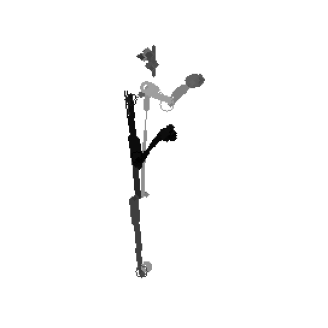

In [11]:
skeleton = construct_skeleton_from_mediapipe_result(
    detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.2,
)

stylized_skel = stylize_as_sketch(skeleton)
plt.figure(figsize=(4, 4))
plt.imshow(stylized_skel.render())
plt.axis("off")
plt.show()

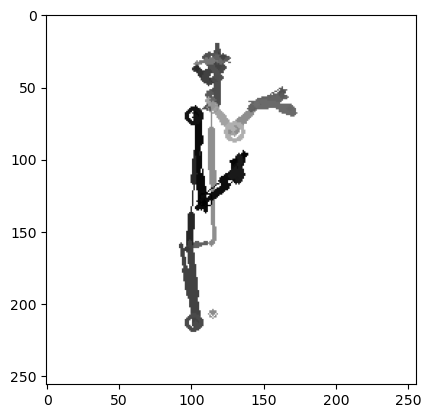

In [12]:
skeleton.jitter_joints(sigma=0.02)
plt.imshow(skeleton.render())

# Creating Heatmaps

In [13]:

def draw_gaussian(heatmap, x, y, H, W, sigma=2):
    for i in range(H):
        for j in range(W):
            heatmap[i,j] = np.exp(-((i-y)**2 + (j-x)**2)/(2*sigma**2))

In [14]:
def construct_bounded_gaussian_from_landmarks(
    detection_result,
    edges,
    H=64,
    W=64,
    sigma=1.5,
    normalize_to_bbox=True,
    bbox_padding=0.15,
):
    """
    Returns:
        heatmaps: (33, H, W)
    """

    # ------------------------
    # 1. Build skeleton
    # ------------------------
    skeleton = construct_skeleton_from_mediapipe_result(
        detection_result,
        edges,
        normalize_to_bbox=normalize_to_bbox,
        bbox_padding=bbox_padding,
    )

    joints = skeleton.joints  # (33,3)
    joint_meta = skeleton.joint_meta

    num_joints = joints.shape[0]
    heatmaps = np.zeros((num_joints, H, W), dtype=np.float32)

    # ------------------------
    # 2. Normalize z for weighting
    # ------------------------
    z_vals = joints[:, 2]
    z_min, z_max = z_vals.min(), z_vals.max()
    z_norm = (z_vals - z_min) / (z_max - z_min + 1e-6)
    weights = 1.0 - z_norm  # closer joints = higher weight

    # ------------------------
    # 3. Precompute grid
    # ------------------------
    y_grid, x_grid = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

    # ------------------------
    # 4. Generate heatmaps
    # ------------------------
    for i in range(num_joints):
        if joint_meta[i]["visibility"] < 0.5:
            continue  # skip invisible joints

        x, y = joints[i, 0], joints[i, 1]

        # convert normalized → pixel
        px = x * (W - 1)
        py = y * (H - 1)

        # Gaussian
        d2 = (x_grid - px) ** 2 + (y_grid - py) ** 2
        gaussian = np.exp(-d2 / (2 * sigma ** 2))

        # apply z-based weight
        gaussian *= weights[i]

        heatmaps[i] = gaussian

    return heatmaps

In [15]:
def show_single_heatmap(heatmaps, joint_idx):
    plt.imshow(heatmaps[joint_idx], cmap='hot')
    plt.title(f"Joint {joint_idx}")
    plt.colorbar()
    plt.show()

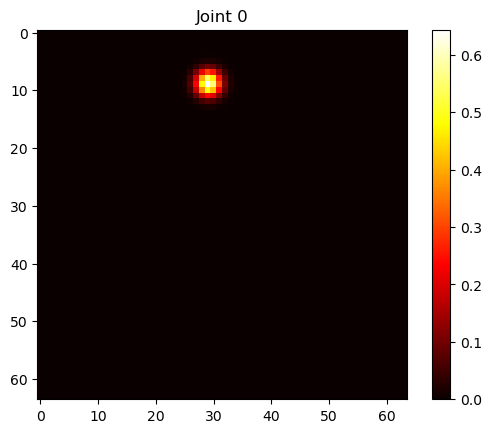

In [16]:
heatmap = construct_bounded_gaussian_from_landmarks(
    detection_result, edges)
show_single_heatmap(heatmap, joint_idx=0)

In [17]:
def overlay_heatmap_on_image(image, heatmap, alpha=0.6):
    """
    image: (H,W) or (H,W,3)
    heatmap: (H,W)
    """
    import cv2

    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]  # RGB

    if len(image.shape) == 2:
        image = np.stack([image]*3, axis=-1) / 255.0
    else:
        image = image / 255.0

    overlay = (1 - alpha) * image + alpha * heatmap_color
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

In [18]:
def show_all_heatmaps(heatmaps):
    combined = np.sum(heatmaps, axis=0)
    plt.imshow(combined, cmap='hot')
    plt.title("All joints combined")
    plt.colorbar()
    plt.show()

In [19]:
def plot_joints_on_image(image, heatmaps):
    import cv2

    H, W = heatmaps.shape[1:]
    img = image.copy()

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    for i in range(heatmaps.shape[0]):
        hm = heatmaps[i]
        y, x = np.unravel_index(np.argmax(hm), hm.shape)

        x_img = int(x * image.shape[1] / W)
        y_img = int(y * image.shape[0] / H)

        cv2.circle(img, (x_img, y_img), 3, (255, 0, 0), 1)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

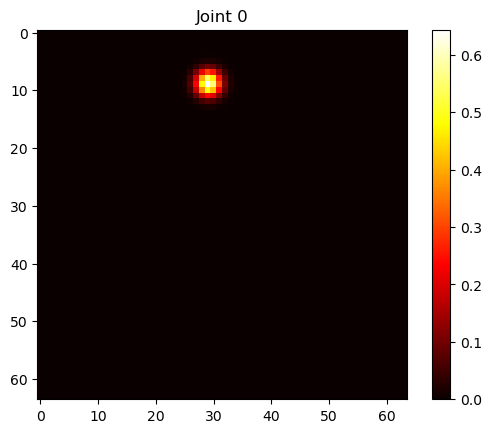

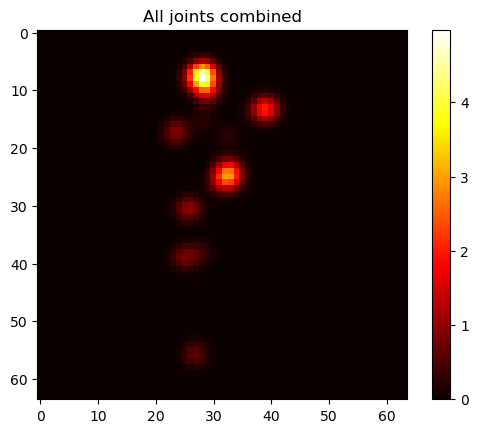

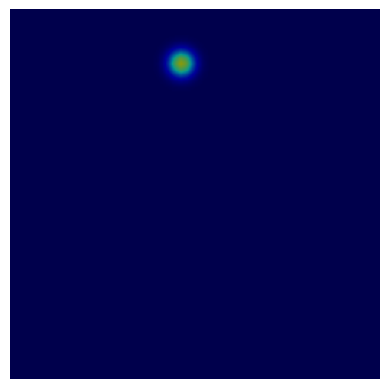

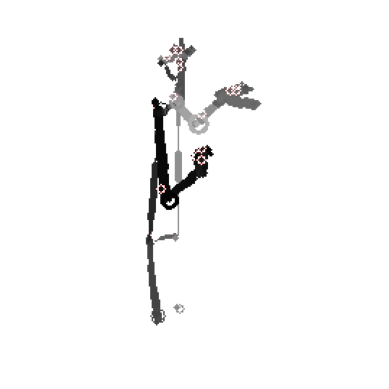

In [20]:
heatmaps = construct_bounded_gaussian_from_landmarks(detection_result, edges)
sketch_img = stylized_skel.render()

show_single_heatmap(heatmaps, 0)
show_all_heatmaps(heatmaps)
overlay_heatmap_on_image(sketch_img[:,:,:3], heatmaps[0])
plot_joints_on_image(sketch_img, heatmaps)

In [21]:
sketch_img

array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       ...,

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], shape=(256, 256, 4), dtype=uint8)

# Create Dataset

In [22]:
def composite_sketch_on_white(sketch_rgba):
    """Blends an RGBA sketch onto a white background to create a standard RGB image."""
    white_bg = np.ones_like(sketch_rgba[:, :, :3]) * 255
    alpha = sketch_rgba[:, :, 3:] / 255.0 
    sketch_rgb = sketch_rgba[:, :, :3]
    final_rgb = (sketch_rgb * alpha + white_bg * (1.0 - alpha))
    return final_rgb.astype(np.uint8)


def create_dataset_from_csv(series, output_folder, edges, sample_limit=5, image_base_path=""):
    """
    series: pandas Series containing image file names/paths.
    image_base_path: optional base path to prepend to values from series.
    """
    base_options = python.BaseOptions(model_asset_path=f"{PATH}/pose_landmarker_full.task")
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=True,
    )
    detector = vision.PoseLandmarker.create_from_options(options)

    output_root = Path(output_folder)
    # Renamed directories to clarify they hold data, not images
    heatmap_dir = output_root / "heatmaps_pkl"
    sketch_dir = output_root / "sketches_pkl"
    heatmap_dir.mkdir(parents=True, exist_ok=True)
    sketch_dir.mkdir(parents=True, exist_ok=True)

    base_path = Path(image_base_path) if image_base_path else None
    
    # List to hold the mapping rows for the CSV
    dataset_mapping = []

    for _, row in tqdm(series.items(), total=len(series)):
        img_filename = str(row).strip()
        if not img_filename or img_filename.lower() == "nan":
            continue

        image_path = (base_path / img_filename) if base_path else Path(img_filename)

        if not image_path.exists():
            print(f"Warning: missing file, skipping: {image_path}")
            continue

        try:
            image = mp.Image.create_from_file(str(image_path))
            detection_result = detector.detect(image)
        except Exception as e:
            print(f"Warning: failed to read/detect {image_path}: {e}")
            continue

        if not detection_result.pose_landmarks:
            print(f"Warning: no pose detected, skipping: {image_path.name}")
            continue

        try:
            skeleton = construct_skeleton_from_mediapipe_result(
                detection_result,
                edges,
                normalize_to_bbox=True,
                bbox_padding=0.2,
            )
            heatmaps = construct_bounded_gaussian_from_landmarks(detection_result, edges)
        except Exception as e:
            print(f"Warning: failed to build skeleton/heatmaps for {image_path.name}: {e}")
            continue

        stem = Path(img_filename).stem
        heatmap_output_path = heatmap_dir / f"{stem}.pkl"
        
        # Save heatmap array as a pickle file
        with open(heatmap_output_path, 'wb') as f:
            pkl.dump(heatmaps, f)

        for i in range(sample_limit):
            stylized_skel = stylize_as_sketch(skeleton)
            sketch_matrix_rgba = stylized_skel.render()
            
            if sketch_matrix_rgba.ndim == 3 and sketch_matrix_rgba.shape[2] == 4:
                sketch_matrix = composite_sketch_on_white(sketch_matrix_rgba)
            else:
                sketch_matrix = sketch_matrix_rgba

            sketch_output_path = sketch_dir / f"{stem}_{i}.pkl"

            # Save the sketch array as a pickle file
            with open(sketch_output_path, 'wb') as f:
                pkl.dump(sketch_matrix, f)
            
            skeleton.jitter_joints(sigma=0.02)

            # Record the relationship in our list
            dataset_mapping.append({
                "input_sketch_pkl": str(sketch_output_path.resolve()),
                "output_heatmap_pkl": str(heatmap_output_path.resolve())
            })

    # Convert the list of dictionaries to a DataFrame and save as CSV
    csv_path = output_root / "dataset_mapping.csv"
    df = pd.DataFrame(dataset_mapping)
    df.to_csv(csv_path, index=False)
    
    print(f"Dataset generation complete. Mapping saved to: {csv_path}")
    
    return df

In [23]:
df = pd.read_csv(f"{PATH}/sample_data.csv")
dataset_map = create_dataset_from_csv(
    df["img_paths"],
    f"{PATH}/CNN_data",
    edges,
    image_base_path=f"{PATH}/mpii_human_pose_v1/images",
)
len(dataset_map)

  0%|          | 3/1000 [00:00<01:41,  9.84it/s]

  1%|▏         | 13/1000 [00:01<01:54,  8.58it/s]

  2%|▏         | 17/1000 [00:02<01:59,  8.22it/s]

  2%|▎         | 25/1000 [00:03<01:55,  8.48it/s]

  3%|▎         | 28/1000 [00:03<01:48,  8.99it/s]

...

 98%|█████████▊| 980/1000 [02:12<00:02,  7.56it/s]

 99%|█████████▉| 994/1000 [02:14<00:00,  9.01it/s]

100%|██████████| 1000/1000 [02:14<00:00,  7.41it/s]


Dataset generation complete. Mapping saved to: C:\Users\leahz\Documents\ATC\pose-project\data\CNN_data\dataset_mapping.csv


4545